# Comparing with NLP(Natural Language Processing)

In [1]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

In [2]:
df = pd.read_csv("file_name.csv")

In [3]:
df["content"] = df["Title"].fillna("") + " " + df["Text"].fillna("")
df = df.dropna(subset=["Political Lean"])

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    df["content"], df["Political Lean"], test_size=0.2, random_state=42
)

In [6]:
vectorizer = TfidfVectorizer(stop_words="english", max_features=2000)
x_train_vec = vectorizer.fit_transform(x_train)
x_test_vec = vectorizer.transform(x_test)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

b = BernoulliNB()
l = LogisticRegression()
d = DecisionTreeClassifier()
r = RandomForestClassifier()
gb= GradientBoostingClassifier()
kn= KNeighborsClassifier()
ab= AdaBoostClassifier()
mn= MultinomialNB()

def algo_test(x, y):
    modeller=[ b, l, d, r, gb, kn, ab, mn]
    isimler=["BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
             "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
             "AdaBoostClassifier", "MultinomialNB"]

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state = 42)
    
    accuracy = []
    precision = []
    recall = []
    f1 = []
    mdl=[]

    print("Veriler hazır modeller deneniyor")
    for model in modeller:
        print(model, " modeli eğitiliyor!..")
        model=model.fit(x_train,y_train)
        tahmin=model.predict(x_test)
        mdl.append(model)
        accuracy.append(accuracy_score(y_test, tahmin))
        precision.append(precision_score(y_test, tahmin, average="micro"))
        recall.append(recall_score(y_test, tahmin, average="micro"))
        f1.append(f1_score(y_test, tahmin, average="micro"))
        print(confusion_matrix(y_test, tahmin))

    print("Eğitim tamamlandı.")
    
    metrics=pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "Model"], index=isimler)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision  
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model"]=mdl

    metrics.sort_values("F1", ascending=False, inplace=True)

    print("En başarılı model: ", metrics.iloc[0].name)
    model=metrics.iloc[0,-1]
    tahmin=model.predict(np.array(x_test) if model==kn else x_test)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print("classification Report:")
    print(classification_report(y_test, tahmin))
    print("Diğer Modeller:")
    
    return metrics.drop("Model", axis=1)

In [13]:
algo_test(x_train_vec,y_train)

Veriler hazır modeller deneniyor
BernoulliNB()  modeli eğitiliyor!..
[[494 222]
 [419 922]]
LogisticRegression()  modeli eğitiliyor!..
[[ 327  389]
 [ 121 1220]]
DecisionTreeClassifier()  modeli eğitiliyor!..
[[ 409  307]
 [ 314 1027]]
RandomForestClassifier()  modeli eğitiliyor!..
[[ 400  316]
 [ 195 1146]]
GradientBoostingClassifier()  modeli eğitiliyor!..
[[ 227  489]
 [  62 1279]]
KNeighborsClassifier()  modeli eğitiliyor!..
[[ 272  444]
 [ 313 1028]]
AdaBoostClassifier()  modeli eğitiliyor!..
[[  93  623]
 [  32 1309]]
MultinomialNB()  modeli eğitiliyor!..
[[ 292  424]
 [  91 1250]]
Eğitim tamamlandı.
En başarılı model:  LogisticRegression
Confusion Matrix:
[[ 327  389]
 [ 121 1220]]
classification Report:
              precision    recall  f1-score   support

Conservative       0.73      0.46      0.56       716
     Liberal       0.76      0.91      0.83      1341

    accuracy                           0.75      2057
   macro avg       0.74      0.68      0.69      2057
weighte

,Accuracy,Precision,Recall,F1
LogisticRegression,0.752066,0.752066,0.752066,0.752066
RandomForestClassifier,0.751580,0.751580,0.751580,0.751580
MultinomialNB,0.749635,0.749635,0.749635,0.749635
GradientBoostingClassifier,0.732134,0.732134,0.732134,0.732134
DecisionTreeClassifier,0.698104,0.698104,0.698104,0.698104
BernoulliNB,0.688381,0.688381,0.688381,0.688381
AdaBoostClassifier,0.681575,0.681575,0.681575,0.681575
KNeighborsClassifier,0.631988,0.631988,0.631988,0.631988


In [7]:
model = MultinomialNB()
model.fit(x_train_vec, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [9]:
y_pred = model.predict(x_test_vec)
accuracy_score(y_test, y_pred)

0.749513807856865

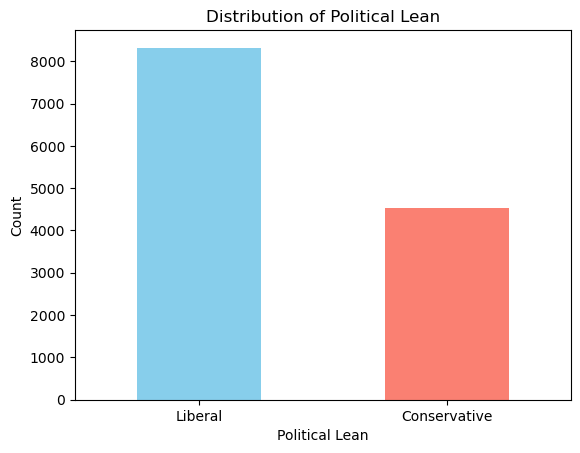

In [14]:
df["Political Lean"].value_counts().plot(
    kind="bar", color=["skyblue", "salmon"]
)
plt.title("Distribution of Political Lean")
plt.xlabel("Political Lean")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [16]:
joblib.dump(model, "nlp_model.pkl")

['nlp_model.pkl']